Data Preprocessing  
1. Analysis of Sensitivity Limits (ASL) Replacement  
2. Outlier Detection — Isolated Forests  
3. Gridding — Sample-Weighted Median  
预处理数据
1. 分析灵敏度限制（ASL）替换  
2. 检验异常值——孤立森林  
3. 网格化——样本数加权中位数  


In [ ]:
import sys
from path_config import *
import myfunction as mf

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

# 函数准备
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from pyod.models.iforest import IForest
import matplotlib.pyplot as plt

def get_outlier(df_x, col_1, col_2, col_3, int_fraction):
    df = df_x.copy()
    scaler = MinMaxScaler(feature_range=(0, 1))
    df[[col_1, col_2, col_3]] = scaler.fit_transform(df[[col_1, col_2, col_3]])
    df[[col_1, col_2, col_3]].head()
    X1 = df[col_1].values.reshape(-1, 1)
    X2 = df[col_2].values.reshape(-1, 1)
    X3 = df[col_3].values.reshape(-1, 1)
    X = np.concatenate((X1, X2, X3), axis=1)
    random_state = np.random.RandomState(1024)
    outliers_fraction = int_fraction
    # 异常值的比例
    # Define seven outlier detection tools to be compared
    classifiers = {
        'Isolation Forest': IForest(contamination=outliers_fraction, random_state=random_state),
    }
    xx, yy, zz = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200), np.linspace(0, 1, 200))
    for i, (clf_name, clf) in enumerate(classifiers.items()):
        clf.fit(X)
        scores_pred = clf.decision_function(X) * -1
        y_pred = clf.predict(X)
        n_inliers = len(y_pred) - np.count_nonzero(y_pred)
        n_outliers = np.count_nonzero(y_pred == 1)
        plt.figure(figsize=(10, 10))
        dfx = df
        dfx['outlier'] = y_pred.tolist()
        IX1 = np.array(dfx[col_1][dfx['outlier'] == 0]).reshape(-1, 1)
        IX2 = np.array(dfx[col_2][dfx['outlier'] == 0]).reshape(-1, 1)
        IX3 = np.array(dfx[col_3][dfx['outlier'] == 0]).reshape(-1, 1)
        OX1 = dfx[col_1][dfx['outlier'] == 1].values.reshape(-1, 1)
        OX2 = dfx[col_2][dfx['outlier'] == 1].values.reshape(-1, 1)
        OX3 = dfx[col_3][dfx['outlier'] == 1].values.reshape(-1, 1)
        print('OUTLIERS : ', n_outliers, 'INLIERS : ', n_inliers, clf_name)
        fig = plt.figure()
        # ax = Axes3D(fig)
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(IX1, IX2, IX3, c='white', s=6, edgecolor='k')
        ax.scatter(OX1, OX2, OX3, c='red', s=6, edgecolor='k')
        # ax.view_init(0, 90)
        plt.xlim((0, 1))
        plt.ylim((0, 1))
        plt.title(clf_name)
        plt.show()
        return dfx

# list_color = ["#ee877c", "#8bd0e3", "#6abeae", "#808eaf", "#f7bba8", "#acb4cc", "#b5e0d5", "#e86462", "#a89687"]

In [ ]:
# ASL 运行一次即可
df_lr_raw = pd.read_csv(path_part + 'lr_raw.csv')
df_sw_raw = pd.read_csv(path_part + 'sw_raw.csv')

df_lr_raw = df_lr_raw[(df_lr_raw['type'] == 0) | ((df_lr_raw['type'] == 1) & (df_lr_raw['limit_value'] < 1))]
df_sw_raw = df_sw_raw[(df_sw_raw['type'] == 0) | ((df_sw_raw['type'] == 1) & (df_sw_raw['limit_value'] < 1))]

df_lr_raw = df_lr_raw[(df_lr_raw['poid'].notna())&(df_lr_raw['spid'].notna())]
df_sw_raw = df_sw_raw[df_sw_raw['poid'].notna()]

df_lr_raw = df_lr_raw[['paid','spid','poid', 'year', 'organ', 'habit', 'lon', 'lat', 'value', 'n']]
df_sw_raw = df_sw_raw[['paid','poid', 'year', 'lon', 'lat', 'sw_value', 'n']]

df_sw_raw = df_sw_raw[df_sw_raw['year'].notna()]

df_lr_raw.to_csv(path_part + 'lr_use.csv', index=False)
df_sw_raw.to_csv(path_part + 'sw_use.csv', index=False)

Let's filter the bio first

In [ ]:
from netCDF4 import Dataset
from scipy.spatial import cKDTree

df_data_raw = pd.read_csv(path_part + "lr_use.csv")
nc_file_path = "C:/Users/dell/OneDrive/file/nc/country_id_1x1.nc"
nc_data = Dataset(nc_file_path, 'r')
lon = nc_data.variables['lon'][:]
lat = nc_data.variables['lat'][:]
country_id = nc_data.variables['country_id'][:]
lon_lat_grid = np.array(np.meshgrid(lon, lat))
grid_shape = lon_lat_grid.shape[1:]
lon_lat_grid = lon_lat_grid.reshape(2, -1).T
tree = cKDTree(lon_lat_grid)
points_to_query = df_data_raw[['lon', 'lat']].values
distances, indices = tree.query(points_to_query)
df_data_raw['country_id'] = country_id.reshape(-1)[indices]
dict_inf = {"sp":['phylum',"class","sp_length","sp_weight","sp_troph", 'rank','family','genus','species'],
             "po":["po_chain","posname",'posid','po_carbon','po_f_carbon','po_classification'],
             'country':['country_code', 'country','continent','income'],
             'habit':['habitat']}
df_data_raw2 = mf.append_inf(df_data_raw, dict_inf)
df_data_raw_select = df_data_raw2[(df_data_raw2['posid'].notna())&(df_data_raw2['rank']=='SPECIES')]
print(df_data_raw2.shape)
print(df_data_raw_select.shape)
df_data_raw_select = mf.df_merge_lat_lon(df_data_raw_select)
# print(df_data_raw_select.dtypes)
print(df_data_raw_select.shape)
print(df_data_raw_select.isnull().sum()[df_data_raw_select.isnull().sum() > 0])
df_data_raw_select.to_csv(path_part0_pre + "lr_use_pre_select.csv", index=False)

(68150, 31)
(64451, 31)
(64451, 32)
sp_length      449
sp_weight    21610
sp_troph       216
dtype: int64


In [3]:
# 看一下各列有多少元素
df_data_raw_select = pd.read_csv(path_part0_pre + "lr_use_pre_select.csv")
list_items = ['posid','spid','class','family','genus','country_code','year','lat_lon']
for item in list_items:
    # print('-------------',item,'--------------------')
    df_item = mf.col_value(df_data_raw_select,item)
    print(item + ' num:',df_item.shape[0])

posid num: 86
spid num: 457
class num: 16
family num: 171
genus num: 335
country_code num: 51
year num: 52
lat_lon num: 1916


C:\Users\dell\AppData\Local\Temp\ipykernel_17416\1702210833.py:2: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df_data_raw_select = pd.read_csv(path_part0_pre + "lr_use_pre_select.csv")


In [7]:
# 看下不同元素的数量和占比
df_data_raw_select = pd.read_csv(path_part0_pre + "lr_use_pre_select.csv")
df_data_raw_select["cl_or"] = df_data_raw_select["class"] + '_' + df_data_raw_select["organ"]
pd.set_option('display.max_rows', None)
print(df_data_raw_select.shape)
list_items = ['posname','class','year','cl_or','po_classification','po_chain','organ']
for item in list_items:
    # print('-------------',item,'--------------------')
    df_item = mf.col_value(df_data_raw_select,item)
    print(df_item)
    # print('-------------',item,'--------------------')

(64494, 33)
           posname  count       per
0             PFOS  10012  0.155239
1             PFDA   4079  0.063246
2           PFUnDA   4038  0.062610
3             PFNA   4008  0.062145
4           PFDoDA   3840  0.059540
5             PFOA   3733  0.057881
6            PFHxS   3457  0.053602
7           PFTrDA   2782  0.043136
8            PFHpA   2511  0.038934
9           PFTeDA   2449  0.037973
10            FOSA   2394  0.037120
11           PFHxA   2365  0.036670
12            PFBS   2218  0.034391
13           PFPeA   1986  0.030794
14            PFBA   1772  0.027475
15            PFDS   1657  0.025692
16           PFHpS   1022  0.015846
17           PFPeS    777  0.012048
18        8:2 FTSA    752  0.011660
19        6:2 FTSA    749  0.011613
20         MeFOSAA    748  0.011598
21         EtFOSAA    745  0.011551
22            PFNS    723  0.011210
23        4:2 FTSA    721  0.011179
24          MeFOSA    482  0.007474
25         HFPO-DA    438  0.006791
26          EtFO

C:\Users\dell\AppData\Local\Temp\ipykernel_17416\421935991.py:2: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df_data_raw_select = pd.read_csv(path_part0_pre + "lr_use_pre_select.csv")


### Data Filtering

In [ ]:
# 筛选fish

df_data_pre = pd.read_csv(path_part0_pre + "lr_use_pre_select.csv", low_memory=False)
print('lr_use_pre shape:', df_data_pre.shape)
list_class = mf.col_value(df_data_pre,'class')['class'].unique().tolist()[0:1]
print('class list:', list_class)
list_organ = ['muscle','liver','whole']

mask = (df_data_pre['class'].isin(list_class)) & (df_data_pre['organ'].isin(list_organ))
df_data_pre_select = df_data_pre[mask].copy()

df_data_pre_select.loc[:, 'year'] = df_data_pre_select['year'].astype(float)
df_data_pre_select.loc[:, 'year'] = df_data_pre_select['year'].astype(int)

mask_year = (df_data_pre_select['year'] <= 2020) & (df_data_pre_select['year'] >= 2000)
df_data_pre_select = df_data_pre_select[mask_year]
print(df_data_pre_select.shape)
# 筛选water
df_sw_all = pd.read_csv(path_part + "sw_use.csv")
print('sw_use shape:', df_sw_all.shape)
df_sw_select = df_sw_all[(df_sw_all['year'].notna())&(df_sw_all['poid'].notna())]
dict_inf = {"poid":['posname']}
df_sw_select = mf.append_inf(df_sw_select,dict_inf)
print(df_sw_select.columns)
# 获取后续分析需要的poid，用于筛选
df_po = pd.read_excel(path_file + "inf.xlsx",sheet_name="po_pfas")
list_po_inf = df_po['poid'][(df_po['log_Koil_w'].notna())&(df_po['density'].notna())].tolist()

df_sp = pd.read_excel(path_file + "inf.xlsx",sheet_name="sp_pfas")
list_sp_inf = df_sp['spid'][(df_sp['sp_length'].notna())&(df_sp['sp_weight'].notna())&(df_sp['sp_troph'].notna())].tolist()


list_po_lr = df_data_pre_select['poid'].unique().tolist()
list_po_sw = df_sw_select['poid'].unique().tolist()

# 三个部分的交集，lr的poid，sw的poid以及inf完整的poid
list_po = list(set(list_po_lr) & set(list_po_sw) & set(list_po_inf))
print('po list:', len(list_po))

df_data_pre_select = df_data_pre_select[df_data_pre_select['poid'].isin(list_po)]
df_data_pre_select = df_data_pre_select[df_data_pre_select['spid'].isin(list_sp_inf)]
df_sw_select = df_sw_select[df_sw_select['poid'].isin(list_po)]
print('lr_select shape:', df_data_pre_select.shape)
print('sw_select shape:', df_sw_select.shape)

df_data_pre_select.to_csv(path_part0_temp + "lr_select.csv",index=False)
df_sw_select.to_csv(path_part0_temp + 'sw_select.csv', index=False)

lr_use_pre shape: (64451, 32)
class list: ['Actinopterygii']
(36108, 32)
sw_use shape: (91422, 7)
Index(['paid', 'poid', 'year', 'lon', 'lat', 'sw_value', 'n', 'posname'], dtype='object')
po list: 39
lr_select shape: (35678, 32)
sw_select shape: (90159, 8)


### fish

包括异常值，加权平均值，网格化，转换和标准化  
Including outliers, weighted averages, gridding, transformation, and standardization

(35678, 32)
OUTLIERS :  245 INLIERS :  35432 Isolation Forest


<Figure size 1000x1000 with 0 Axes>

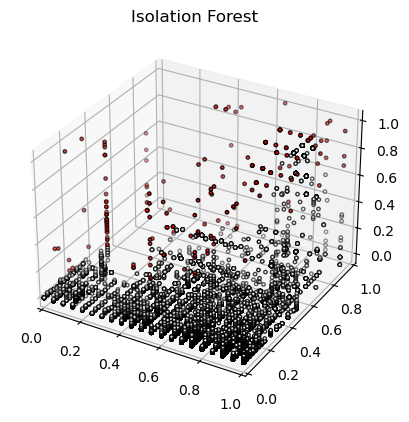

(35432, 9)


In [ ]:

df_data_pre_select = pd.read_csv(path_part0_temp + "lr_select.csv")
print(df_data_pre_select.shape)
df_icicle_w_o_outlier = df_data_pre_select.copy()

df_icicle_w_o_outlier['year_count'] = df_icicle_w_o_outlier.groupby('posname')['year'].transform('nunique')
df_icicle_w_o_outlier['value_median'] = df_icicle_w_o_outlier.groupby('posname')['value'].transform('median')

sorted_posnames = df_icicle_w_o_outlier.groupby('posname').agg({
    'year_count': 'first',
    'value_median': 'first'
}).sort_values(['year_count', 'value_median'], ascending=[False, False]).index

posname_rank = {name: rank for rank, name in enumerate(sorted_posnames)}
df_icicle_w_o_outlier['posname_rank'] = df_icicle_w_o_outlier['posname'].map(posname_rank)


le_ind = LabelEncoder()
po_le = le_ind.fit_transform(df_icicle_w_o_outlier["posname_rank"])

df_icicle_w_o_outlier["po_copy"] = po_le
df_icicle_w_o_outlier["po_copy"] = po_le
df_icicle_w_o_outlier['value_copy'] = (df_icicle_w_o_outlier['value'] - df_icicle_w_o_outlier.groupby('po_copy')['value'].transform('min')) / (df_icicle_w_o_outlier.groupby('po_copy')['value'].transform('max') - df_icicle_w_o_outlier.groupby('po_copy')['value'].transform('min'))
df_icicle_w_o_outlier["year_copy"] = df_icicle_w_o_outlier["year"]

df_icicle_w_o_outlier = df_icicle_w_o_outlier.dropna(subset=["year_copy","po_copy","value_copy"])
df_icicle_w_o_outlier = get_outlier(df_icicle_w_o_outlier,"year_copy", "po_copy","value_copy", 0.01)

df_icicle_w_o_outlier = df_icicle_w_o_outlier[df_icicle_w_o_outlier["outlier"]==0]

list_3 = ["habitat","spid","posname","lon","lat","organ","year", "value", 'n']
list_4 = ["habitat","spid","lon","lat","organ","year",'n']
df_icicle_w_o_outlier = df_icicle_w_o_outlier[list_3]
print(df_icicle_w_o_outlier.shape)
df_icicle_w_o_outlier.to_csv(path_part0_temp + "lr_outlier.csv",index=False)


In [14]:
# 加权去N



df_outlier = pd.read_csv(path_part0_temp + "lr_outlier.csv")
print(df_outlier.shape)
list_1 = ["habitat","spid","posname","lon","lat","organ","year"]
list_2 = ["habitat","spid","posname","lon","lat","organ","year", "n","value"]
list_3 = ["habitat","spid","posname","lon","lat","organ","year", "value"]
df_icicle = df_outlier[list_2]
df_icicle_w = mf.get_weight_count(df_icicle,list_1,'mean') 
# 先计算各坐标的加权中位数值，比较花时间，因为写的循环
df_icicle_w_o = df_icicle_w[list_3]
print(df_icicle_w_o.shape)
df_icicle_w_o.to_csv(path_part0_temp + "lr_weight.csv",index=False)

#1 min

(35410, 9)
['n', 'value']
habitat~spid~posname~lon~lat~organ~year
['habitat~spid~posname~lon~lat~organ~year', 'n', 'value']
26393
(26393, 8)


In [15]:
# 1°×1°
df_weight = pd.read_csv(path_part0_temp + "lr_weight.csv")
print(df_weight.shape)
int_grid = 1
def lat_lon_to_grid(lat, lon, grid_size=1):
    return round(lat / grid_size) * grid_size, round(lon / grid_size) * grid_size


df_weight['lat_grid'], df_weight['lon_grid'] = zip(*df_weight.apply(lambda row: lat_lon_to_grid(row['lat'], row['lon'], int_grid), axis=1))

# 对同一网格内habit spid organ time_year po_name相同的数据取value的中位数
df_grid = df_weight.groupby(['lat_grid', 'lon_grid', 'habitat', 'spid', 'organ', 'year', 'posname'])['value'].mean().reset_index()
print(df_grid.shape)
df_grid = df_grid[df_grid['habitat'].isin(['Inland_water', 'Ocean'])]
df_grid.to_csv(path_part0_pre + "lr_grid.csv",index=False)

(26393, 8)
(21607, 8)


In [ ]:
import pandas as pd
df_grid = pd.read_csv(path_part0_pre + "lr_grid.csv")
df_grid['habitat'] = df_grid['habitat'].replace({'Inland_water': 0, 'Ocean': 1})

organ_dummies = pd.get_dummies(df_grid['organ'], prefix='organ')

if 'organ_whole' in organ_dummies.columns:
    organ_dummies = organ_dummies.drop('organ_whole', axis=1)

df_grid = pd.concat([df_grid, organ_dummies], axis=1)

df_grid = df_grid.drop('organ', axis=1)

df_lr_treat = df_grid.copy()
df_type = pd.read_csv("C:/Users/dell/OneDrive/file/nc/type_data.csv")

df_lr_treat = pd.merge(df_lr_treat, df_type, 
                  left_on=['lat_grid', 'lon_grid'], 
                  right_on=['lat', 'lon'], 
                  how='left')
columns_to_drop = ['lon', 'lat']
df_lr_treat = df_lr_treat.drop(columns=columns_to_drop)

df_lr_treat.to_csv(path_part0_pre + "lr.csv",index=False)
print(df_lr_treat.isnull().sum()[df_lr_treat.isnull().sum() > 0])
df_lr_treat1 = mf.preprocess(df_lr_treat, 'log', ['value'])
df_lr_treat1.to_csv(path_part0_pre + "lr_log.csv",index=False)
df_lr_treat2 = mf.preprocess(df_lr_treat, 'box_cox', ['value'])
df_lr_treat2.to_csv(path_part0_pre + "lr_bc.csv",index=False)
df_lr_treat3 = mf.preprocess(df_lr_treat2, 'standardization', ['value'])
df_lr_treat3.to_csv(path_part0_pre + "lr_treat.csv",index=False)

Series([], dtype: int64)
列 value 的Box-Cox变换参数 λ: -0.10690673258210305


### water

包括异常值，加权平均值，网格化，转换和标准化  
Including outliers, weighted averages, gridding, transformation, and standardization

(90159, 8)
paid         int64
poid       float64
year       float64
lon        float64
lat        float64
value      float64
n            int64
posname     object
dtype: object
OUTLIERS :  884 INLIERS :  89275 Isolation Forest


<Figure size 1000x1000 with 0 Axes>

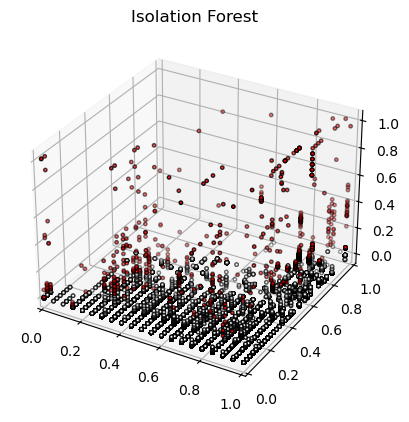

(89275, 7)


In [ ]:

df_data_pre_select = pd.read_csv(path_part0_temp + "sw_select.csv")

df_data_pre_select = df_data_pre_select.rename(columns={'sw_value': 'value'})
df_data_pre_select = df_data_pre_select[df_data_pre_select['value']>0]
print(df_data_pre_select.shape)
df_icicle_w_o_outlier = df_data_pre_select.copy()
# df_icicle_w_o_outlier['value'] = df_icicle_w_o_outlier['value'].astype(float)
print(df_icicle_w_o_outlier.dtypes)


# 对 posname 进行排序
df_icicle_w_o_outlier['year_count'] = df_icicle_w_o_outlier.groupby('posname')['year'].transform('nunique')
df_icicle_w_o_outlier['value_median'] = df_icicle_w_o_outlier.groupby('posname')['value'].transform('median')

sorted_posnames = df_icicle_w_o_outlier.groupby('posname').agg({
    'year_count': 'first',
    'value_median': 'first'
}).sort_values(['year_count', 'value_median'], ascending=[False, False]).index

posname_rank = {name: rank for rank, name in enumerate(sorted_posnames)}
df_icicle_w_o_outlier['posname_rank'] = df_icicle_w_o_outlier['posname'].map(posname_rank)

# 使用排序后的 posname_rank 进行编码
le_ind = LabelEncoder()
po_le = le_ind.fit_transform(df_icicle_w_o_outlier["posname_rank"])


df_icicle_w_o_outlier["po_copy"] = po_le
df_icicle_w_o_outlier['value_copy'] = (df_icicle_w_o_outlier['value'] - df_icicle_w_o_outlier.groupby('po_copy')['value'].transform('min')) / (df_icicle_w_o_outlier.groupby('po_copy')['value'].transform('max') - df_icicle_w_o_outlier.groupby('po_copy')['value'].transform('min'))
df_icicle_w_o_outlier["year_copy"] = df_icicle_w_o_outlier["year"]
df_icicle_w_o_outlier = get_outlier(df_icicle_w_o_outlier,"year_copy", "po_copy","value_copy", 0.01)

df_icicle_w_o_outlier = df_icicle_w_o_outlier[df_icicle_w_o_outlier["outlier"]==0]

list_3 = ["lon","lat","posname","year", "value", 'n', 'poid']

df_icicle_w_o_outlier = df_icicle_w_o_outlier[list_3]
print(df_icicle_w_o_outlier.shape)
df_icicle_w_o_outlier.to_csv(path_part0_temp + 'sw_outlier.csv',index=False)

In [17]:
# 加权去N
df_outlier = pd.read_csv(path_part0_temp + 'sw_select.csv')

print(df_outlier.shape)
list_1 = ["posname","lon","lat","year"]
list_2 = ["posname","lon","lat","year", "n","value"]
list_3 = ["posname","lon","lat","year", "value"]
df_icicle = df_outlier[list_2]
# median, mean
df_icicle_w = mf.get_weight_count(df_icicle,list_1,'mean') 

df_icicle_w_o = df_icicle_w[list_3]
print(df_icicle_w_o.shape)
df_icicle_w_o.to_csv(path_part0_temp + 'sw_weight_no_outlier.csv',index=False)

# 5min

(90159, 8)
['value', 'n']
posname~lon~lat~year
['posname~lon~lat~year', 'value', 'n']
52985
(52985, 5)


In [ ]:
# 加权去N
df_outlier = pd.read_csv(path_part0_temp + 'sw_outlier_test2.csv')
print(df_outlier.shape)
list_1 = ["posname","lon","lat","year"]
list_2 = ["posname","lon","lat","year", "n","value"]
list_3 = ["posname","lon","lat","year", "value"]
df_icicle = df_outlier[list_2]
# median, mean
df_icicle_w = mf.get_weight_count(df_icicle,list_1,'mean') 

df_icicle_w_o = df_icicle_w[list_3]
print(df_icicle_w_o.shape)
df_icicle_w_o.to_csv(path_part0_temp + 'sw_weight_test2.csv',index=False)

# 5min

(89373, 7)
['value', 'n']
posname~lon~lat~year
['posname~lon~lat~year', 'value', 'n']
52492
(52492, 5)


In [ ]:
# 1°×1°
df_weight = pd.read_csv(path_part0_temp + 'sw_weight.csv')
print(df_weight.shape)
int_grid = 1
def lat_lon_to_grid(lat, lon, grid_size=1):
    return round(lat / grid_size) * grid_size, round(lon / grid_size) * grid_size


df_weight['lat_grid'], df_weight['lon_grid'] = zip(*df_weight.apply(lambda row: lat_lon_to_grid(row['lat'], row['lon'], int_grid), axis=1))

df_grid = df_weight.groupby(['lat_grid', 'lon_grid', 'year', 'posname'])['value'].mean().reset_index()
# df_grid = df_weight.groupby(['lat_grid', 'lon_grid', 'year', 'posname'])['value'].median().reset_index()
print(df_grid.shape)

df_grid.to_csv(path_part0_pre + 'sw_grid.csv',index=False)

(52429, 5)
(14008, 5)


In [ ]:
import pandas as pd
df_grid = pd.read_csv(path_part0_pre + "sw_grid.csv")

df_sw_treat = df_grid.copy()


df_type = pd.read_csv("C:/Users/dell/OneDrive/file/nc/type_data.csv")

df_sw_treat = pd.merge(df_sw_treat, df_type, 
                  left_on=['lat_grid', 'lon_grid'], 
                  right_on=['lat', 'lon'], 
                  how='left')

print(df_sw_treat.isnull().sum()[df_sw_treat.isnull().sum() > 0])
columns_to_drop = ['lon', 'lat']
df_sw_treat = df_sw_treat.drop(columns=columns_to_drop)
print(df_sw_treat['value'].median())
print(df_sw_treat['value'].mean())

df_sw_treat.to_csv(path_part0_pre + "sw.csv",index=False)


Series([], dtype: int64)
0.3075
26.98370463454784


### inf

处理污染物与物种的协变量  
Covariates for Pollutants and Species  

In [ ]:
# 筛出需要的po和sp
import sys
sys.path.append('..')
from path_config import *

import myfunction as mf
import pandas as pd
import numpy as np

df_po = pd.read_excel(path_file + "inf.xlsx",sheet_name="po_pfas")
list_po_inf = df_po['poid'][(df_po['log_Koil_w'].notna())&(df_po['density'].notna())].tolist()
print('po inf num:', len(list_po_inf))
df_po = df_po[df_po['poid'].isin(list_po_inf)]
print(df_po.isnull().sum()[df_po.isnull().sum() > 0])
df_po.to_csv(path_part0_pre + "po_select.csv",index=False)

df_lr_select = pd.read_csv(path_part0_temp + 'lr_select.csv')
list_sp_lr = df_lr_select['spid'].unique().tolist()

df_sp = pd.read_excel(path_file + "inf.xlsx",sheet_name="sp_pfas")
df_sp = df_sp[df_sp['spid'].isin(list_sp_lr)]
print('sp inf num:', df_sp.shape[0])
print(df_sp.isnull().sum()[df_sp.isnull().sum() > 0])
df_sp.to_csv(path_part0_pre + "sp_select.csv",index=False)


po inf num: 60
po_oname    29
po_fname    23
RfD         45
dtype: int64
sp inf num: 263
latinname    109
dtype: int64


In [ ]:
# 预处理po，sp
# 连续变量转换后标准化，log开头的不动
# 文本变量虚拟化，一些调用代码，二元直接赋值
df_po = pd.read_csv(path_part0_pre + "po_select.csv")
df_sp = pd.read_csv(path_part0_pre + "sp_select.csv")

# "po_classification"这个分类变量后面不用,"po_chain"二元直接赋值,
list_po_auto = ["po_m_w","log_Px","log_Koc", "log_Kow","log_Kaw",
                    "log_Koa","log_Koa_wet","log_KHxd_air","log_Koil_w","log_Koil_air","density",
                    "solubility", "log_pKa", "log_D5_5", "log_D7_4"]

list_sp_auto = ["sp_length","sp_weight","sp_troph"]

df_po_transformation1 = mf.preprocess(df_po, 'log', list_po_auto)
df_sp_transformation1 = mf.preprocess(df_sp, 'log', list_sp_auto)
df_po_transformation1.to_csv(path_part0_pre + "po_log.csv",index=False)
df_sp_transformation1.to_csv(path_part0_pre + "sp_log.csv",index=False)

# standardization normalization
df_po_standardization = mf.preprocess(df_po_transformation1, 'standardization', list_po_auto)
df_sp_standardization = mf.preprocess(df_sp_transformation1, 'standardization', list_sp_auto)

df_po_standardization.to_csv(path_part0_pre + "po_treat.csv",index=False)
df_sp_standardization.to_csv(path_part0_pre + "sp_treat.csv",index=False)

### dist

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


class DistributionAnalyzer:
    def __init__(self, file_path, value_col='value', cuts=3, font="SimHei"):
        """
        参数:
        file_path: str   
        value_col: str   
        cuts: int     
        font: str   
        """
        self.file_path = file_path
        self.value_col = value_col
        self.cuts = cuts

        plt.rcParams['font.sans-serif'] = [font]
        plt.rcParams['axes.unicode_minus'] = False

        self.df = None
        self.df_results = None

    def read_data(self):
        """读取数据并检查列"""
        self.df = pd.read_csv(self.file_path)
        if self.value_col not in self.df.columns:
            raise ValueError(f"数据中没有 '{self.value_col}' 列！")

    def analyze_distribution(self, data, name):
        """返回 分布指标字典"""
        data = data.dropna()
        skew = stats.skew(data)
        kurt = stats.kurtosis(data)  # Fisher 定义：正态应为 0
        try:
            shapiro_stat, shapiro_p = stats.shapiro(data)
        except:
            shapiro_stat, shapiro_p = np.nan, np.nan
        return {
            '变换': name,
            '样本数': len(data),
            '偏度': skew,
            '峰度': kurt,
            'Shapiro W': shapiro_stat,
            'Shapiro p值': shapiro_p
        }

    def split_by_quantile(self, df_data):
        """按分位数切分列"""
        df_copy = df_data.copy()
        quantiles = np.linspace(0, 1, self.cuts + 1)
        bins = df_copy[self.value_col].quantile(quantiles).values
        bins = np.unique(bins)  # 去重
        labels = [f"[{bins[i]:.4f}, {bins[i+1]:.4f})" for i in range(len(bins) - 1)]

        df_copy['range'] = pd.cut(
            df_copy[self.value_col],
            bins=bins,
            labels=labels,
            include_lowest=True,
            right=False
        )
        return df_copy, labels, bins

    def run_analysis(self, plot_global=True, plot_bins=True):
        """运行整体与分段分析"""
        self.read_data()
        values = self.df[self.value_col].dropna()

        results = []
        # 原始
        results.append(self.analyze_distribution(values, '原始'))

        # log(x)
        vals_pos = values[values > 0]
        results.append(self.analyze_distribution(np.log(vals_pos), 'log(x)'))

        # log(x+1)
        results.append(self.analyze_distribution(np.log1p(values), 'log(x+1)'))

        # Box-Cox
        if len(vals_pos) > 0:
            bc_vals, bc_lambda = stats.boxcox(vals_pos)
            results.append(self.analyze_distribution(pd.Series(bc_vals),
                                                     f'Box-Cox λ={bc_lambda:.4f}'))
        self.df_results = pd.DataFrame(results)
        print("\n=== 整体分布对比 ===")
        print(self.df_results)

        # 绘制整体分布
        if plot_global:
            fig, axs = plt.subplots(1, 4, figsize=(20, 4))
            sns.histplot(values, bins=50, kde=True, ax=axs[0])
            axs[0].set_title('原始')

            sns.histplot(np.log(vals_pos), bins=50, kde=True, ax=axs[1])
            axs[1].set_title('log(x)')

            sns.histplot(np.log1p(values), bins=50, kde=True, ax=axs[2])
            axs[2].set_title('log(x+1)')

            sns.histplot(bc_vals, bins=50, kde=True, ax=axs[3])
            axs[3].set_title(f'Box-Cox λ={bc_lambda:.4f}')
            plt.tight_layout()
            plt.show()




e:\progress\anaconda2\lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 14008.
  res = hypotest_fun_out(*samples, **kwds)



=== 整体分布对比 ===
                 变换    样本数         偏度           峰度  Shapiro W     Shapiro p值
0                原始  14008  50.064850  3052.493071   0.022421  1.566943e-124
1            log(x)  14008  -0.075889     0.052356   0.996307   2.792794e-18
2          log(x+1)  14008   2.354544     7.107904   0.709238   4.399626e-93
3  Box-Cox λ=0.0083  14008   0.000406     0.052590   0.996631   2.368065e-17


e:\progress\anaconda2\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
e:\progress\anaconda2\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
e:\progress\anaconda2\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
e:\progress\anaconda2\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

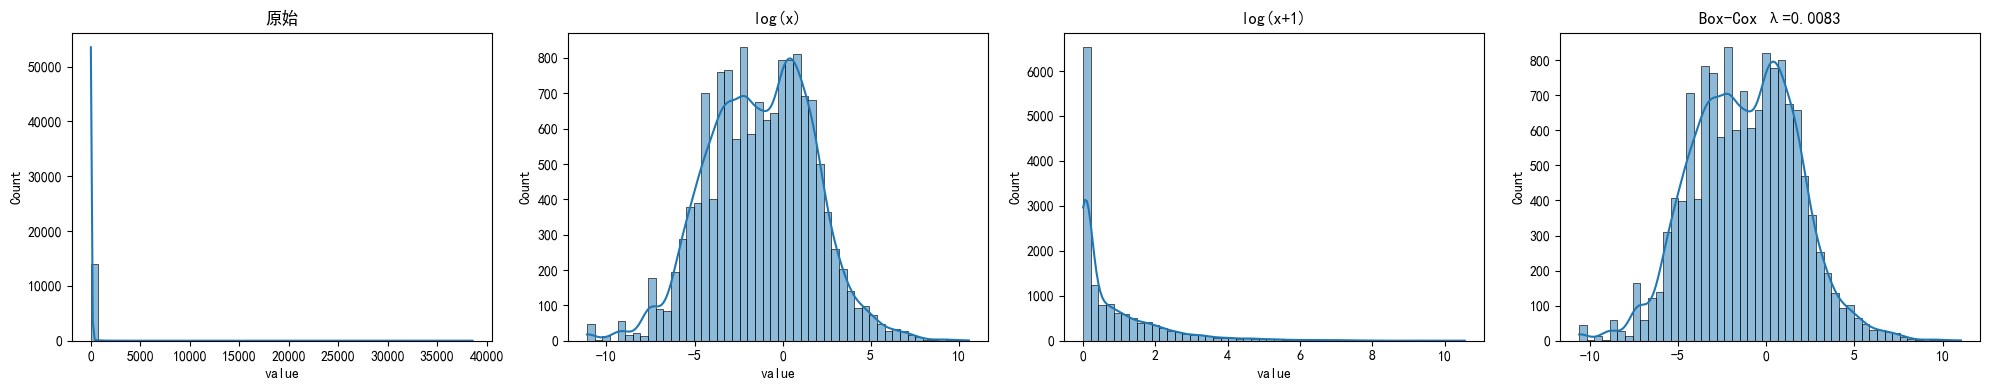

In [8]:

analyzer = DistributionAnalyzer(
    file_path=r"E:\wyy\code_project\running_outcome\final_data\SPDB\part0_treat\pretreatment\sw.csv",
    value_col='value',
    cuts=3
)
analyzer.run_analysis(plot_global=True, plot_bins=True)


e:\progress\anaconda2\lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 21558.
  res = hypotest_fun_out(*samples, **kwds)
e:\progress\anaconda2\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):



=== 整体分布对比 ===
                  变换    样本数         偏度           峰度  Shapiro W     Shapiro p值
0                 原始  21558  41.303306  2436.144936   0.061465  3.003863e-136
1             log(x)  21558   0.774730     1.096952   0.948653   2.694914e-64
2           log(x+1)  21558   3.022622    10.447155   0.570943  3.463637e-114
3  Box-Cox λ=-0.1069  21558  -0.058802     1.261240   0.971845   8.214817e-53


e:\progress\anaconda2\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
e:\progress\anaconda2\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
e:\progress\anaconda2\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


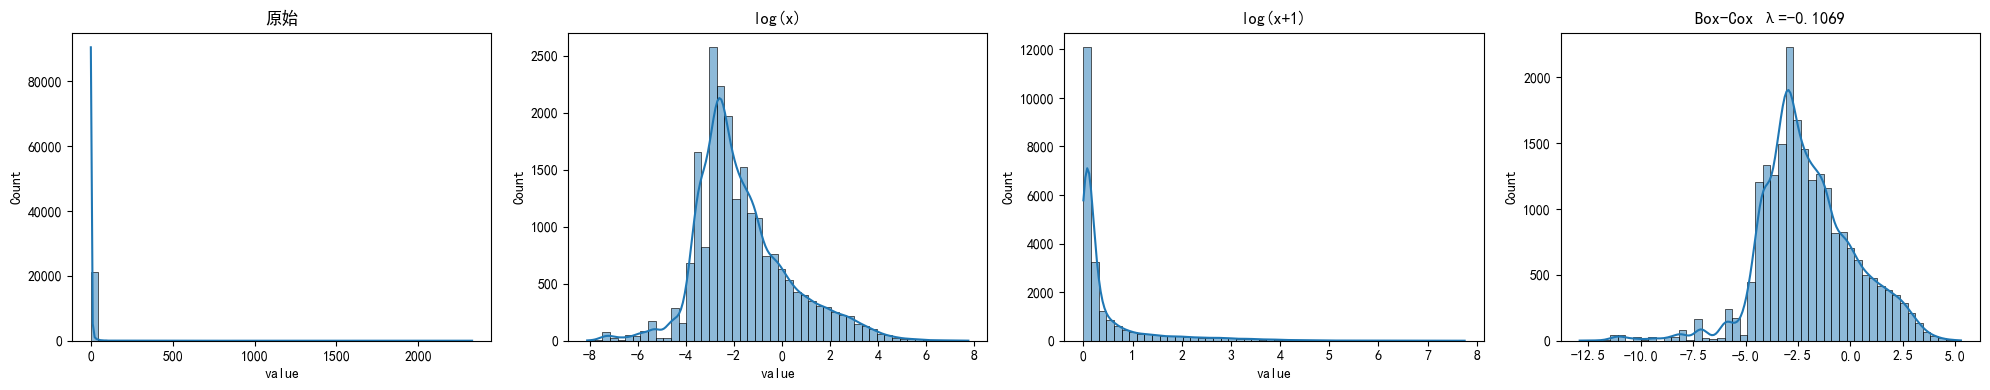

In [9]:

analyzer = DistributionAnalyzer(
    file_path=r"E:\wyy\code_project\running_outcome\final_data\SPDB\part0_treat\pretreatment\lr.csv",
    value_col='value',
    cuts=3
)
analyzer.run_analysis(plot_global=True, plot_bins=True)
